In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_hermite, gammaln

from core.IntensityModes import hermite_gauss as Hg, hermite_gauss_1d as Hg_1d, laguerre_gauss as Lg
from core.Polarization_elements import polarizers,scalar_to_vector, filter_polarizer,q_plate as qp
from core.masks import turbulence_mask as turb
from core.metrics import intensity as I, power as pwr, phase as phi, inner_product as dp
from core.Optical_elements import angular_spectrum as angSpec, tilt, mirror, beam_splitter as bs, lens

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from PIL import Image

from tqdm import trange

In [ ]:
x = np.linspace(-2e-2,2e-2,4000)
y = np.linspace(-2e-2,2e-2,4000)
x,y = np.meshgrid(x,y)
z1 =.2
z2=.2

m=10
hg = Hg(x, y, m)
arm1,arm2 = bs(hg)


# Separating modes

(<Figure size 640x480 with 1 Axes>, <Axes: >)

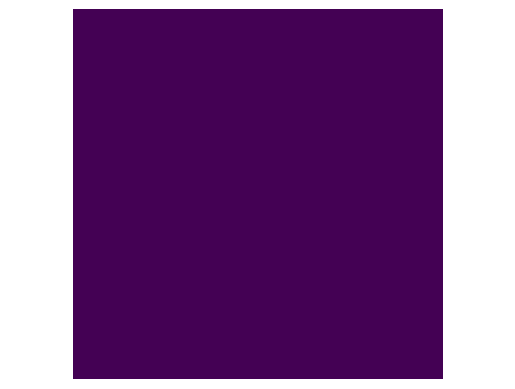

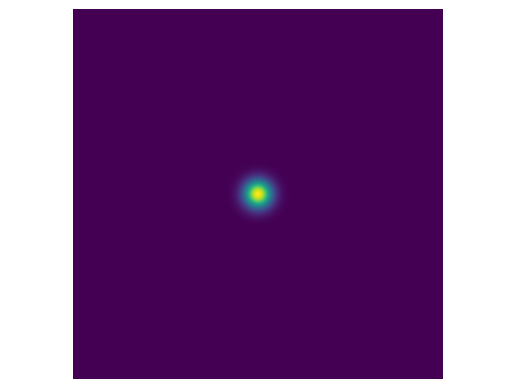

In [12]:
x = np.linspace(-1e-2,1e-2,4000)
y = np.linspace(-1e-2,1e-2,4000)
x,y = np.meshgrid(x,y)
z = 1


m=0
hg = Hg(x, y, m)
arm1,arm2 = bs(hg)

arm1 = angSpec(arm1, x, y, z=z/2)
arm1 = mirror(arm1, x, y)
arm1 = angSpec(arm1, x, y, z=z/2)

arm2 = angSpec(arm2, x, y, z=z/2)
arm2 = mirror(arm2, x, y)
arm2 = angSpec(arm2, x, y, z=z/2)


out1,out2 = bs(arm1,arm2)

#out2 = lens(out2, x, y, f=z/2)
out2 = angSpec(out2, x, y, z=z/2)

I(out1)
I(out2)


# Propagating

In [30]:
arm2_ = arm2[::-1,::-1]

(<Figure size 640x480 with 1 Axes>, <Axes: >)

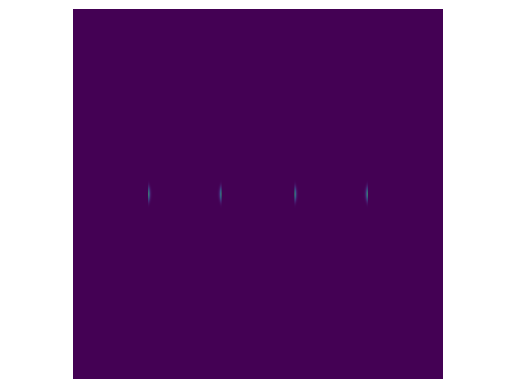

In [ ]:
'''
arm1 = angSpec(arm1, x, y, z=z1)
arm1 = mirror(arm1, x, y)
arm1 = angSpec(arm1, x, y, z=z1)
'''
arm1 = -arm1 # mesma coisa que fazer o que está em cima

arm2 = angSpec(arm2, x, y, z=z2/2)
arm2 = lens(arm2, x, y, f=z2/2)
arm2 = angSpec(arm2, x, y, z=z2/2)
arm2 = mirror(arm2, x, y)
arm2 = angSpec(arm2, x, y, z=z2/2)
arm2 = lens(arm2, x, y, f=z2/2)
arm2 = angSpec(arm2, x, y, z=z2/2)
I(arm2-arm2_)

# Reuniting modes

In [27]:
out1,out2 = bs(arm1,arm2)
print(pwr(x,y,out1), pwr(x,y,out2))

0.9999056080747627 9.439192549263564e-05


(<Figure size 640x480 with 1 Axes>, <Axes: >)

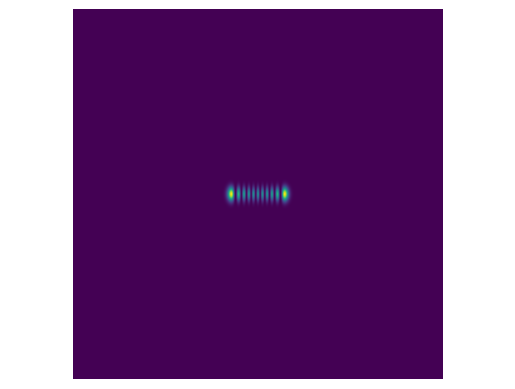

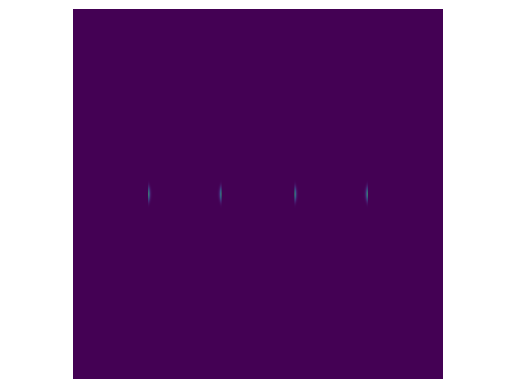

In [28]:
I(out1)
I(out2)

# Deslocamento externo
##### além do deslocamento tem uma diferença de caminho devido ao bs

0.03000750187547377
1.0000000000003253


KeyboardInterrupt: 

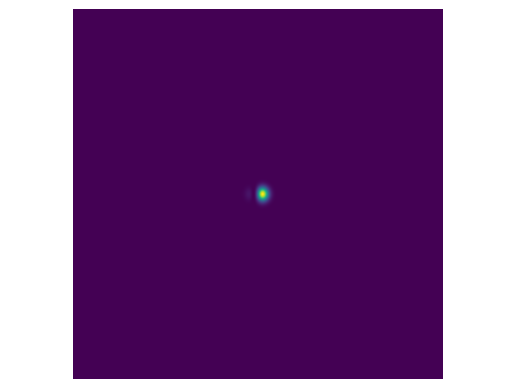

In [ ]:
dx = x[0,1] - x[0,0]
z1 =.2
f = z1/2
n = 1

factor = n*dx/1e-3
print(factor)
m=0
hg = 1/np.sqrt(2)*(Hg(x, y, m) + Hg(x, y, m+1))
I(hg)
print(pwr(x,y,hg))
arm1,arm2 = bs(hg)
arm2 = -arm2
arm2 = np.roll(arm2,n*1) # n*dx de deslocamento << 1
'''
arm1 = angSpec(arm1, x, y, z=f)
arm1 = lens(arm1, x, y, f=f)
arm1 = angSpec(arm1, x, y, z=f)
arm1 = mirror(arm1)
arm1 = angSpec(arm1, x, y, z=f)
arm1 = lens(arm1, x, y, f=f)
arm1 = angSpec(arm1, x, y, z=f)
'''
arm1 = arm1[::-1,::-1]

out1,out2 = bs(arm1,arm2)
pw1 = pwr(x,y,out1)
pw2 = pwr(x,y,out2)

print(pw1, pw2)
print(pw1 - pw2)
print('signal:', np.abs(pw1 - pw2))

I(out1)
I(out2)

In [23]:
np.linspace(0,1e-2,11)

array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
       0.009, 0.01 ])

In [60]:
signal =[]
z1 =.2
for i in range(10):
    dx = x[0,1] - x[0,0]
    z1 =.2
    f = z1/2
    n = 1


    hg = Hg(x, y, i)

    arm1,arm2 = bs(hg,None)
    arm2 = -np.roll(arm2,30, axis=1)

    '''
    arm1 = angSpec(arm1, x, y, z=z1/2)
    arm1 = lens(arm1, x, y, f=z1/2)
    arm1 = angSpec(arm1, x, y, z=z1/2)
    arm1 = mirror(arm1)
    arm1 = angSpec(arm1, x, y, z=z1/2)
    arm1 = lens(arm1, x, y, f=z1/2)
    arm1 = angSpec(arm1, x, y, z=z1/2)
    '''

    arm1 = arm1[::-1,::-1]

    out1,out2 = bs(arm1,arm2)
    pw1 = pwr(x,y,out1)
    pw2 = pwr(x,y,out2)

    print(i)
    signal.append(pw1+pw2-np.abs(pw1 - pw2))
    


0
1
2
3
4
5
6
7
8
9


In [61]:
signal

[np.float64(0.04402403593700677),
 np.float64(0.13010490775856043),
 np.float64(0.21231020280197888),
 np.float64(0.290756246526065),
 np.float64(0.36555674575764674),
 np.float64(0.4368228358505284),
 np.float64(0.504663127136705),
 np.float64(0.5691837506789423),
 np.float64(0.6304884033337234),
 np.float64(0.6886783921334655)]

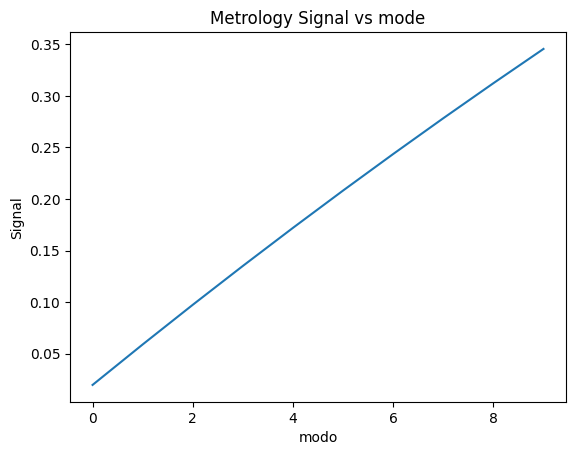

In [59]:
plt.plot(signal)
plt.xlabel('modo')
plt.ylabel('Signal')
plt.title('Metrology Signal vs mode')
plt.show()

#I(out1)
#I(out2)

2.0000000000006506
1.9999499762425026 5.002375814820253e-05
1.9998999524843544
signal: 1.9998999524843544
1.9997999199818148
1.999749911235548 5.000874626811992e-05
1.9996999024892799
signal: 1.9996999024892799
1.9991999200853554
1.9991499563446993 4.996374065713493e-05
1.999099992604042
signal: 1.999099992604042
1.9982007203110284
1.99815083147971 4.988883131894967e-05
1.998100942648391
signal: 1.998100942648391
1.9968035190584927
1.996753734890513 4.978416797974995e-05
1.9967039507225333
signal: 1.9967039507225333
1.9950099907321082
1.9949603407724392 4.9649959669286704e-05
1.9949106908127698
signal: 1.9949106908127698
1.992822282397047
1.992772795922911 4.94864741365014e-05
1.9927233094487744
signal: 1.9927233094487744
1.9902430094960568
1.9901937154589562 4.929403710179555e-05
1.9901444214218544
signal: 1.9901444214218544
1.9872752506388431
1.9872261776074953 4.907303134862846e-05
1.9871771045761466
signal: 1.9871771045761466
1.9839225414785986
1.983873717582942 4.882389565770078e-

(<Figure size 640x480 with 1 Axes>, <Axes: >)

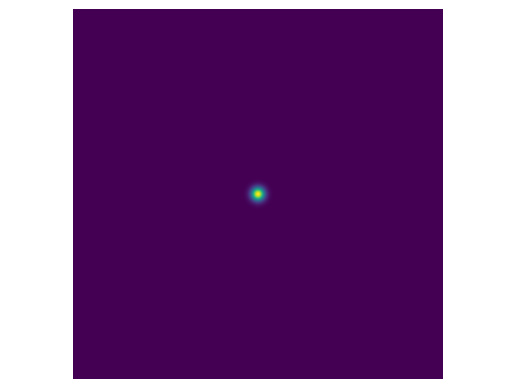

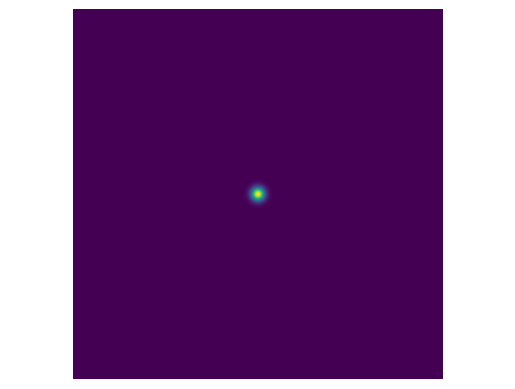

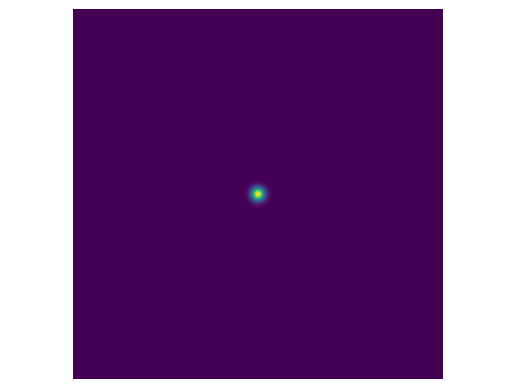

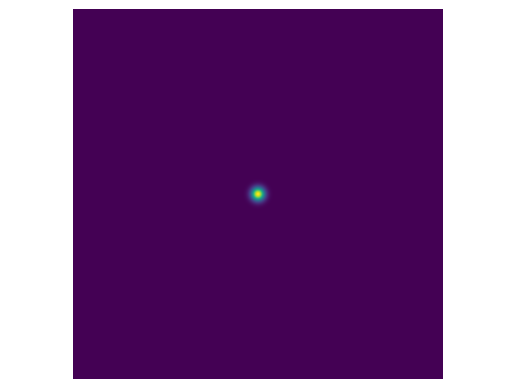

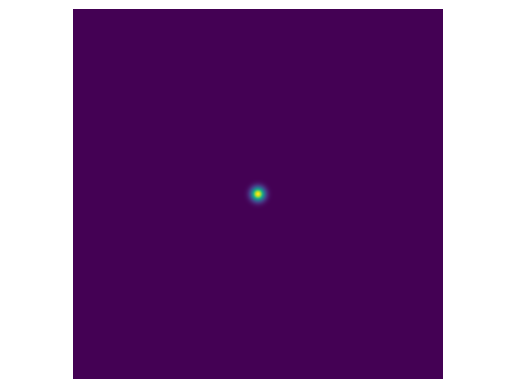

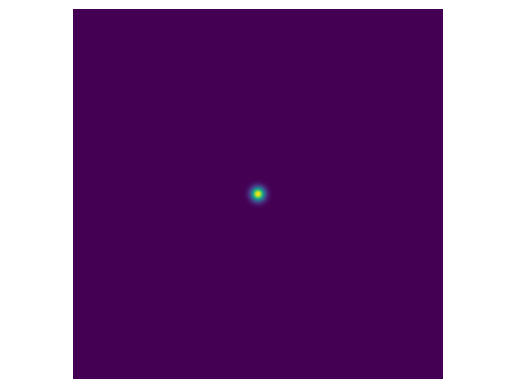

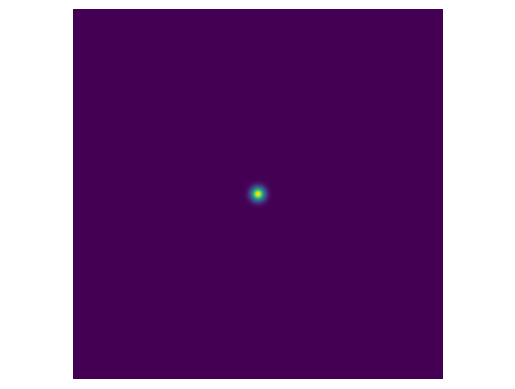

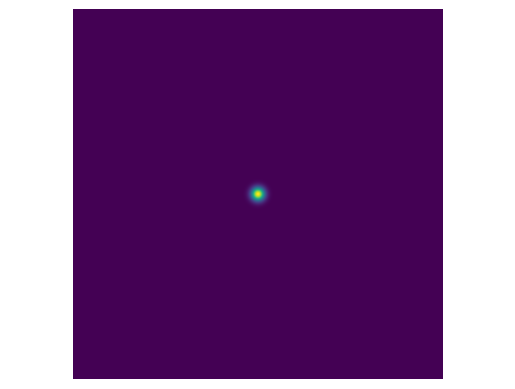

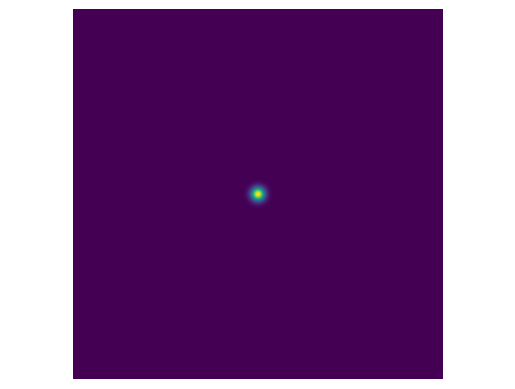

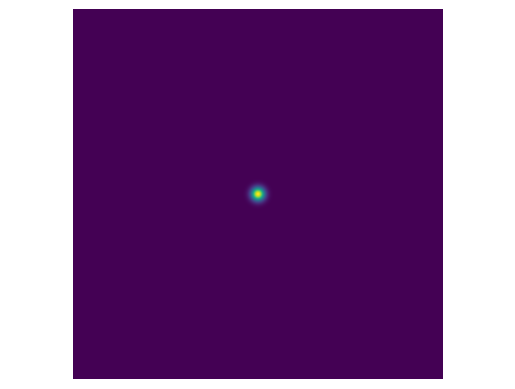

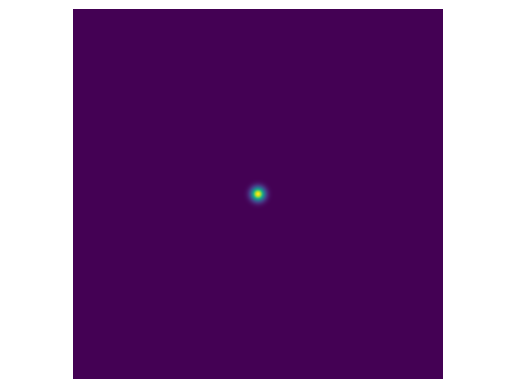

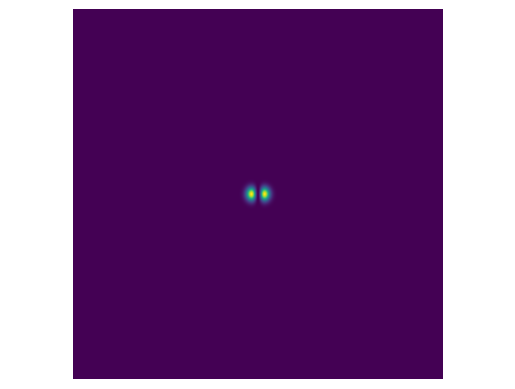

In [62]:
for i in range(10):
    dx = i*(x[0,1] - x[0,0])
    z1 =.2
    f = z1/2

    hg = 1/np.sqrt(2)*(Hg(x + dx, y) + Hg(x - dx, y))

    I(hg)
    print(pwr(x,y,hg))

    arm1,arm2 = bs(hg)

    arm2 = np.roll(arm2,n*1)
    arm2 = -arm2
    arm1 = arm1[::-1,::-1]

    out1,out2 = bs(arm1,arm2)
    pw1 = pwr(x,y,out1)
    pw2 = pwr(x,y,out2)

    print(pw1, pw2)
    print(pw1 - pw2)
    print('signal:', np.abs(pw1 - pw2))

I(out1)
I(out2)